# Dataset Breast Cancer - Scikit-Learn

**Estudiante:** Romina Vera  
**Asignatura:** Aprendizaje Automático

**Curso:** CDDEIA-ELMA-4-1

**Fecha:** Junio 2026

## 1. Importación de librerías


In [172]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# División de datos
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LogisticRegression

# Métricas
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# Validación cruzada
from sklearn.model_selection import cross_val_score

# Optimización
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

## 2. Carga y exploración del dataset

In [173]:
# Cargar dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Crear DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Información general del dataset

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### Estadísticas descriptivas

In [175]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### Distribución de la variable objetivo

In [177]:
print(data.target_names)
df["target"].value_counts()

['malignant' 'benign']


,count
target,
1,357
0,212


## Distribución de clases

> Añadir blockquote



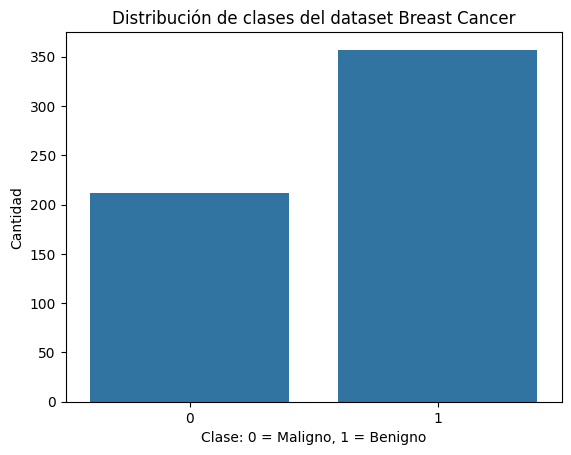

In [176]:
sns.countplot(x="target", data=df)

plt.title("Distribución de clases del dataset Breast Cancer")
plt.xlabel("Clase: 0 = Maligno, 1 = Benigno")
plt.ylabel("Cantidad")
plt.show()

### Interpretación de la distribución de clases

El dataset contiene dos clases: tumores malignos y benignos. Se observa que la clase benigna tiene mayor cantidad de registros que la clase maligna, por lo que existe un ligero desbalance. Por esta razón, es importante evaluar el modelo con métricas como Precision, Recall, F1-Score y AUC-ROC.

## 3. División de datos

In [178]:
# Variable objetivo
TARGET = "target"

# Variables predictoras
FEATURES = list(data.feature_names)

# Separación de variables
X = df[FEATURES]
y = df[TARGET]

# División entrenamiento-prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=38,
    stratify=y
)

print(f"Datos de entrenamiento: {X_train.shape[0]}")
print(f"Datos de prueba: {X_test.shape[0]}")

Datos de entrenamiento: 455
Datos de prueba: 114


### Interpretación

Se definió la variable objetivo (`target`) y las variables predictoras del conjunto de datos. Posteriormente, se realizó una división del 80% para entrenamiento y 20% para prueba utilizando un muestreo estratificado (`stratify=y`), garantizando que la proporción de tumores benignos y malignos se conserve en ambos conjuntos.

## 4. Entrenamiento del modelo de Regresión Logística

In [179]:
# Creación el modelo
modelo = LogisticRegression(max_iter=5000)

# Entrenamiento el modelo
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


### Interpretación

Se entrenó un modelo de Regresión Logística utilizando los datos de entrenamiento para aprender patrones que permitan clasificar los tumores como benignos o malignos.

Predicciones

In [188]:
# Realizar predicciones
y_pred = modelo.predict(X_test)

### Interpretación

El modelo generó predicciones sobre los datos de prueba, permitiendo comparar los resultados estimados con los valores reales.

## 5. Evaluación del modelo

### Matriz de Confusión

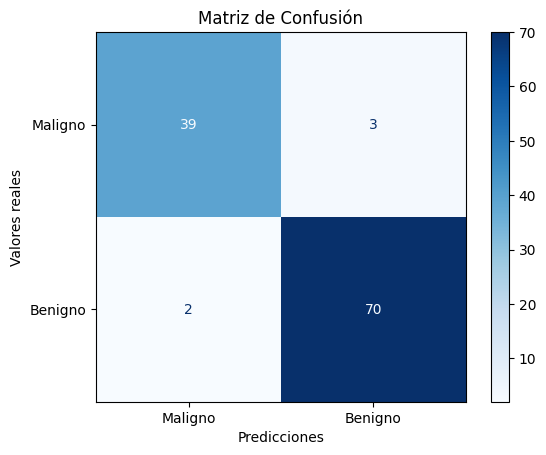

In [181]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Maligno", "Benigno"]
)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusión")
plt.xlabel("Predicciones")
plt.ylabel("Valores reales")

plt.show()

### Métricas de clasificación

In [182]:
# Probabilidades para AUC-ROC
y_prob = modelo.predict_proba(X_test)[:, 1]

# Métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Tabla de métricas
metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"],
    "Resultado": [accuracy, precision, recall, f1, auc]
})

metricas

,Métrica,Resultado
0,Accuracy,0.956140
1,Precision,0.958904
2,Recall,0.972222
3,F1-Score,0.965517
4,AUC-ROC,0.995370


### Curva ROC y AUC-ROC

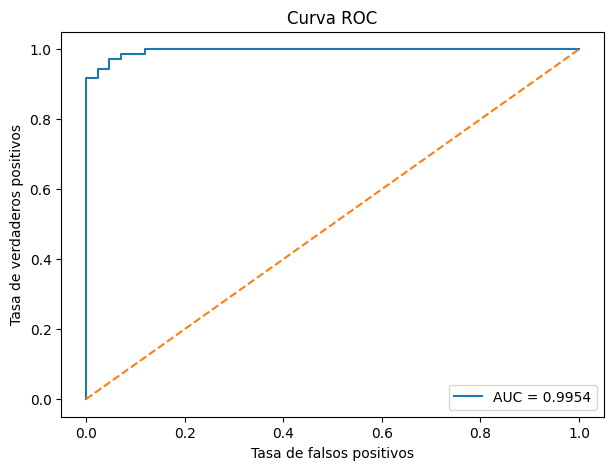

In [183]:
# Calculo de valores para la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Grafica curva ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Curva ROC")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.show()

## 6. Validación Cruzada K-Fold

In [184]:
# Validación cruzada con k=5
scores_k5 = cross_val_score(
    modelo,
    X,
    y,
    cv=5,
    scoring="f1"
)

# Validación cruzada con k=10
scores_k10 = cross_val_score(
    modelo,
    X,
    y,
    cv=10,
    scoring="f1"
)

validacion = pd.DataFrame({
    "Método": ["K-Fold (k=5)", "K-Fold (k=10)"],
    "Exactitud promedio": [
        scores_k5.mean(),
        scores_k10.mean()
    ],
    "Desviación estándar": [
        scores_k5.std(),
        scores_k10.std()
    ]
})

validacion

,Método,Exactitud promedio,Desviación estándar
0,K-Fold (k=5),0.961188,0.014032
1,K-Fold (k=10),0.964136,0.018116


### Interpretación

Los resultados obtenidos con k=5 y k=10 son similares, lo que indica que el modelo mantiene un rendimiento estable al evaluar diferentes particiones del conjunto de datos.

## 7. Optimización de hiperparámetros con GridSearchCV y RandomizedSearchCV

In [185]:
# Espacio de búsqueda de hiperparámetros
param_grid = [
    {
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "penalty": ["l1", "l2"],
        "solver": ["liblinear"]
    },
    {
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs"]
    }
]

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_grid=param_grid,
    cv=5,
    scoring="f1"
)

# Configurar RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=10000),
    param_distributions={
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "penalty": ["l1", "l2"],
        "solver": ["liblinear"]
    },
    n_iter=6,
    cv=5,
    scoring="f1",
    random_state=42
)

# Entrenar ambos métodos
grid_search.fit(X_train, y_train)
random_search.fit(X_train, y_train)

# Mostrar resultados
print("Resultados de la Optimización:\n")

print("Mejores parámetros GridSearchCV:")
print(grid_search.best_params_)
print("Mejor F1-Score Grid:", round(grid_search.best_score_, 4))
print()

print("Mejores parámetros RandomizedSearchCV:")
print(random_search.best_params_)
print("Mejor F1-Score Random:", round(random_search.best_score_, 4))
print()

print(
    "Tiempo total GridSearchCV:",
    round(grid_search.cv_results_["mean_fit_time"].sum(), 4),
    "segundos"
)

print(
    "Tiempo total RandomizedSearchCV:",
    round(random_search.cv_results_["mean_fit_time"].sum(), 4),
    "segundos"
)

# Tabla comparativa
comparacion_busqueda = pd.DataFrame({
    "Método": ["GridSearchCV", "RandomizedSearchCV"],
    "Mejor F1-Score": [
        grid_search.best_score_,
        random_search.best_score_
    ],
    "Tiempo (s)": [
        grid_search.cv_results_["mean_fit_time"].sum(),
        random_search.cv_results_["mean_fit_time"].sum()
    ]
})

comparacion_busqueda

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Resultados de la Optimización:

Mejores parámetros GridSearchCV:
{'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor F1-Score Grid: 0.9719

Mejores parámetros RandomizedSearchCV:
{'solver': 'liblinear', 'penalty': 'l1', 'C': 100}
Mejor F1-Score Random: 0.9719

Tiempo total GridSearchCV: 6.1533 segundos
Tiempo total RandomizedSearchCV: 1.3685 segundos


,Método,Mejor F1-Score,Tiempo (s)
0,GridSearchCV,0.971928,6.153348
1,RandomizedSearchCV,0.971928,1.368483


### Interpretación

GridSearchCV evaluó todas las combinaciones posibles de hiperparámetros, mientras que RandomizedSearchCV analizó únicamente una muestra aleatoria de ellas. Con ambos métodos se pudo encontrar configuraciones con un alto rendimiento

## 8. Ajuste del umbral de decisión

In [186]:
# Probabilidades de la clase positiva
y_prob = modelo.predict_proba(X_test)[:, 1]

umbrales = [0.4, 0.5, 0.6]

resultados = []

for umbral in umbrales:

    y_pred_umbral = (y_prob >= umbral).astype(int)

    resultados.append([
        umbral,
        precision_score(y_test, y_pred_umbral),
        recall_score(y_test, y_pred_umbral),
        f1_score(y_test, y_pred_umbral)
    ])

comparacion_umbral = pd.DataFrame(
    resultados,
    columns=["Umbral", "Precisión", "Recall", "F1-Score"]
)

comparacion_umbral

,Umbral,Precisión,Recall,F1-Score
0,0.4,0.958904,0.972222,0.965517
1,0.5,0.958904,0.972222,0.965517
2,0.6,0.958904,0.972222,0.965517
